In [1]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

In [2]:
df_news = pd.read_csv("data/raw/financial_news.csv")
df_news.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/financial_news.csv'

In [3]:
import os
os.getcwd()

'c:\\Users\\Acer\\Documents\\news-sentiment-analysis\\notebooks'

In [4]:
df_news = pd.read_csv("../data/raw/financial_news.csv")

In [5]:
df_stock = pd.read_csv("../data/raw/sample_stocks.csv")

In [6]:
import os
print(os.listdir("../data/raw"))

['.ipynb_checkpoints', 'financial_news.csv', 'sample_stock2.csv', 'sample_stocks.csv']


In [7]:
df_news = pd.read_csv("../data/raw/financial_news.csv")
df_stock = pd.read_csv("../data/raw/sample_stocks.csv")

In [8]:
import pandas as pd

df_news = pd.read_csv("../data/raw/financial_news.csv")
df_news.head()

,headline,sentiment
0,Stock market rises after tech rally,positive
1,Company reports huge quarterly losses,negative
2,Investors remain cautious amid inflation,neutral
3,Bank stocks surge on strong earnings,positive
4,Oil prices fall due to weak demand,negative


In [9]:
mapping = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

df_news["sentiment_score"] = df_news["sentiment"].map(mapping)
df_news.head()

,headline,sentiment,sentiment_score
0,Stock market rises after tech rally,positive,1
1,Company reports huge quarterly losses,negative,-1
2,Investors remain cautious amid inflation,neutral,0
3,Bank stocks surge on strong earnings,positive,1
4,Oil prices fall due to weak demand,negative,-1


In [10]:
df_news["date"] = pd.to_datetime(df_news["date"])

daily_sentiment = df_news.groupby(df_news["date"].dt.date)["sentiment_score"].mean()
daily_sentiment.head()

KeyError: 'date'

In [11]:
df_news.columns

Index(['headline', 'sentiment', 'sentiment_score'], dtype='str')

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import numpy as np

In [13]:
df_news = pd.read_csv("../data/raw/financial_news.csv")
df_stock = pd.read_csv("../data/raw/sample_stocks.csv")

In [14]:
df_news.head()

,headline,sentiment
0,Stock market rises after tech rally,positive
1,Company reports huge quarterly losses,negative
2,Investors remain cautious amid inflation,neutral
3,Bank stocks surge on strong earnings,positive
4,Oil prices fall due to weak demand,negative


In [15]:
df_stock.head()

,Date,Open,High,Low,Close,Volume
0,2024-01-02,186.09,187.50,184.22,185.85,82488700
1,2024-01-03,184.22,185.88,183.43,184.25,58414500
2,2024-01-04,182.15,183.09,180.63,181.91,71983500
3,2024-01-05,181.99,182.75,180.17,181.18,62099900
4,2024-01-08,182.09,185.60,181.34,185.56,59144500


In [16]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "positive"
    elif polarity < 0:
        return "negative"
    else:
        return "neutral"

In [17]:
df_news["sentiment"] = df_news["headline"].apply(get_sentiment)

df_news.head()

,headline,sentiment
0,Stock market rises after tech rally,neutral
1,Company reports huge quarterly losses,positive
2,Investors remain cautious amid inflation,neutral
3,Bank stocks surge on strong earnings,positive
4,Oil prices fall due to weak demand,negative


In [18]:
mapping = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

df_news["sentiment_score"] = df_news["sentiment"].map(mapping)

df_news.head()

,headline,sentiment,sentiment_score
0,Stock market rises after tech rally,neutral,0
1,Company reports huge quarterly losses,positive,1
2,Investors remain cautious amid inflation,neutral,0
3,Bank stocks surge on strong earnings,positive,1
4,Oil prices fall due to weak demand,negative,-1


In [19]:
df_news["date"] = pd.date_range(start="2024-01-01", periods=len(df_news))

df_news.head()

,headline,sentiment,sentiment_score,date
0,Stock market rises after tech rally,neutral,0,2024-01-01
1,Company reports huge quarterly losses,positive,1,2024-01-02
2,Investors remain cautious amid inflation,neutral,0,2024-01-03
3,Bank stocks surge on strong earnings,positive,1,2024-01-04
4,Oil prices fall due to weak demand,negative,-1,2024-01-05


In [20]:
df_stock["Date"] = pd.to_datetime(df_stock["Date"])

df_stock.head()

,Date,Open,High,Low,Close,Volume
0,2024-01-02,186.09,187.50,184.22,185.85,82488700
1,2024-01-03,184.22,185.88,183.43,184.25,58414500
2,2024-01-04,182.15,183.09,180.63,181.91,71983500
3,2024-01-05,181.99,182.75,180.17,181.18,62099900
4,2024-01-08,182.09,185.60,181.34,185.56,59144500


In [21]:
df_stock["returns"] = df_stock["Close"].pct_change()

df_stock.head()

,Date,Open,High,Low,Close,Volume,returns
0,2024-01-02,186.09,187.50,184.22,185.85,82488700,NaN
1,2024-01-03,184.22,185.88,183.43,184.25,58414500,-0.008609
2,2024-01-04,182.15,183.09,180.63,181.91,71983500,-0.012700
3,2024-01-05,181.99,182.75,180.17,181.18,62099900,-0.004013
4,2024-01-08,182.09,185.60,181.34,185.56,59144500,0.024175


In [22]:
daily_sentiment = df_news.groupby("date")["sentiment_score"].mean().reset_index()

daily_sentiment.head()

,date,sentiment_score
0,2024-01-01,0.0
1,2024-01-02,1.0
2,2024-01-03,0.0
3,2024-01-04,1.0
4,2024-01-05,-1.0


In [23]:
merged = pd.merge(
    df_stock,
    daily_sentiment,
    left_on="Date",
    right_on="date",
    how="inner"
)

merged.head()

,Date,Open,High,Low,Close,Volume,returns,date,sentiment_score
0,2024-01-02,186.09,187.50,184.22,185.85,82488700,NaN,2024-01-02,1.0
1,2024-01-03,184.22,185.88,183.43,184.25,58414500,-0.008609,2024-01-03,0.0
2,2024-01-04,182.15,183.09,180.63,181.91,71983500,-0.012700,2024-01-04,1.0
3,2024-01-05,181.99,182.75,180.17,181.18,62099900,-0.004013,2024-01-05,-1.0
4,2024-01-08,182.09,185.60,181.34,185.56,59144500,0.024175,2024-01-08,0.0


In [24]:
merged[["sentiment_score", "returns"]].corr()

,sentiment_score,returns
sentiment_score,1.000000,-0.111873
returns,-0.111873,1.000000


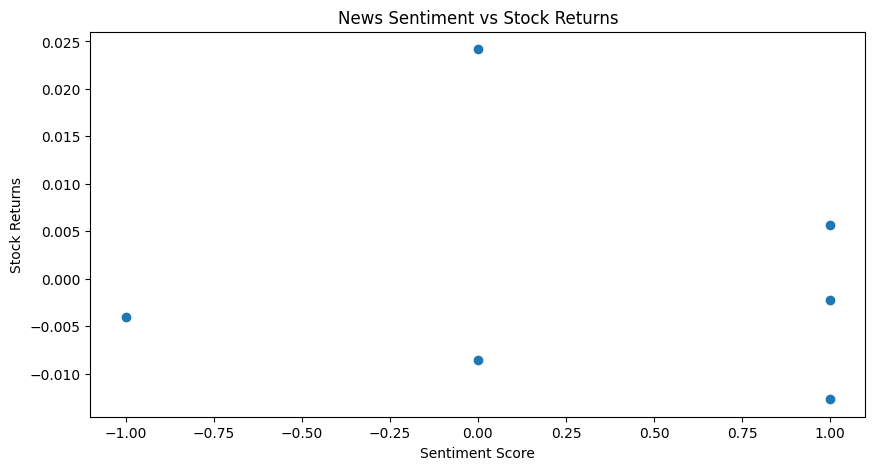

In [25]:
plt.figure(figsize=(10,5))

plt.scatter(merged["sentiment_score"], merged["returns"])

plt.title("News Sentiment vs Stock Returns")
plt.xlabel("Sentiment Score")
plt.ylabel("Stock Returns")

plt.show()

## Interpretation

The visualization shows the relationship between financial news sentiment and stock returns. Positive sentiment is associated with positive stock movement in some cases, while negative sentiment may correspond with declining returns. This suggests that news sentiment could provide useful signals for market behavior analysis.